# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/belbino/global-fuel-prices-20202026/global_fuel_prices_2020_2026.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/belbino/global-fuel-prices-20202026/global_fuel_prices_2020_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


## last Five row

In [4]:
df.tail()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
27463,2026-03-09,Rwanda,Africa,Low,Low,3.036,2.849,2.294,130.0,62.3
27464,2026-03-16,Rwanda,Africa,Low,Low,3.020,2.861,2.248,130.0,43.3
27465,2026-03-23,Rwanda,Africa,Low,Low,3.072,2.825,2.334,130.0,64.1
27466,2026-03-30,Rwanda,Africa,Low,Low,3.045,2.816,2.282,130.0,43.7
27467,2026-04-06,Rwanda,Africa,Low,Low,3.064,2.846,2.296,130.0,63.7


## Shape of our dataset

In [5]:
df.shape

(27468, 10)

## List out all columns

In [6]:
df.columns

Index(['date', 'country', 'region', 'income_level', 'subsidy_level',
       'petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter',
       'brent_crude_usd', 'tax_percentage'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

date                 object
country              object
region               object
income_level         object
subsidy_level        object
petrol_usd_liter    float64
diesel_usd_liter    float64
lpg_usd_liter       float64
brent_crude_usd     float64
tax_percentage      float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27468 entries, 0 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              27468 non-null  object 
 1   country           27468 non-null  object 
 2   region            27468 non-null  object 
 3   income_level      27468 non-null  object 
 4   subsidy_level     27468 non-null  object 
 5   petrol_usd_liter  27468 non-null  float64
 6   diesel_usd_liter  27468 non-null  float64
 7   lpg_usd_liter     27468 non-null  float64
 8   brent_crude_usd   27468 non-null  float64
 9   tax_percentage    27468 non-null  float64
dtypes: float64(5), object(5)
memory usage: 2.1+ MB


## Check Null Value

In [9]:
df.isnull().sum()

date                0
country             0
region              0
income_level        0
subsidy_level       0
petrol_usd_liter    0
diesel_usd_liter    0
lpg_usd_liter       0
brent_crude_usd     0
tax_percentage      0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
count,27468.000000,27468.000000,27468.000000,27468.000000,27468.000000
mean,2.281915,2.133760,1.711473,106.686453,26.774468
std,1.540612,1.465058,1.155543,18.972391,17.203349
min,0.010000,0.010000,0.010000,47.970000,0.000000
25%,0.926000,0.858000,0.695000,101.140000,13.500000
50%,2.116500,1.954500,1.588000,112.270000,23.400000
75%,3.457000,3.231000,2.590000,119.410000,38.900000
max,6.779000,6.240000,5.100000,130.000000,65.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

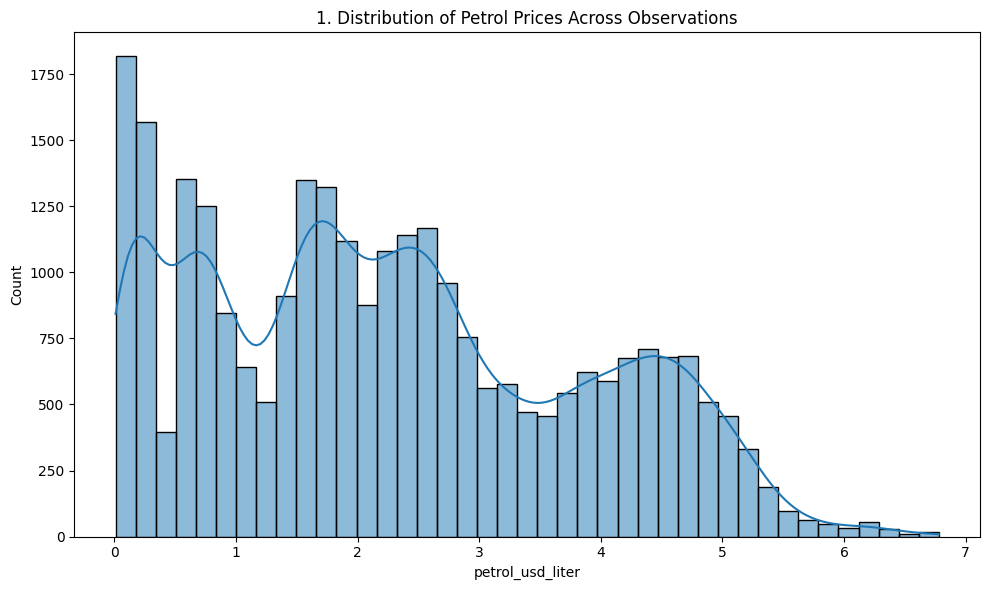

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['petrol_usd_liter'], kde=True)
plt.title(f'{plot_no}. Distribution of Petrol Prices Across Observations')
show_fig()
plot_no += 1

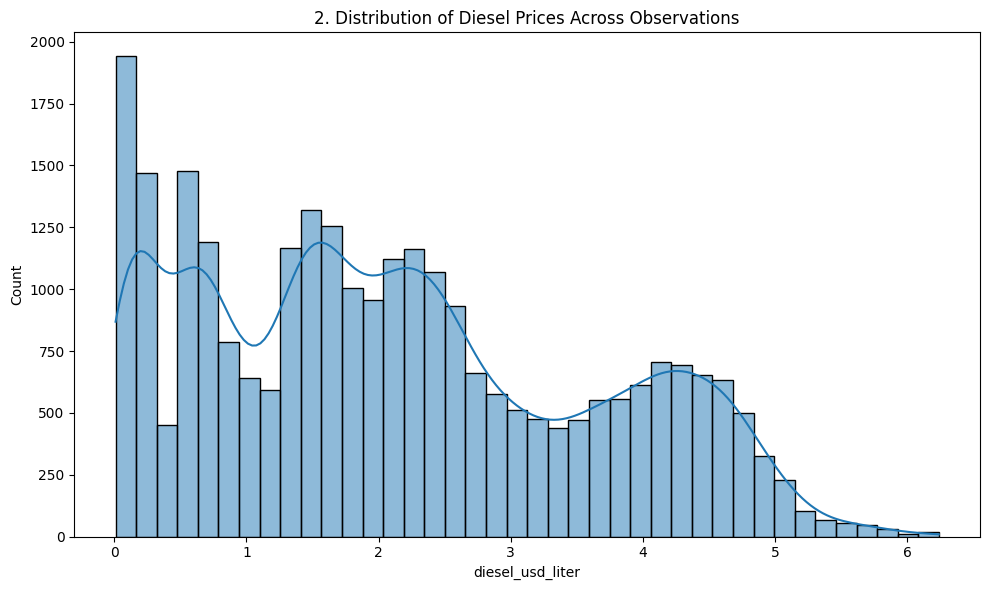

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['diesel_usd_liter'], kde=True)
plt.title(f'{plot_no}. Distribution of Diesel Prices Across Observations')
show_fig()
plot_no += 1

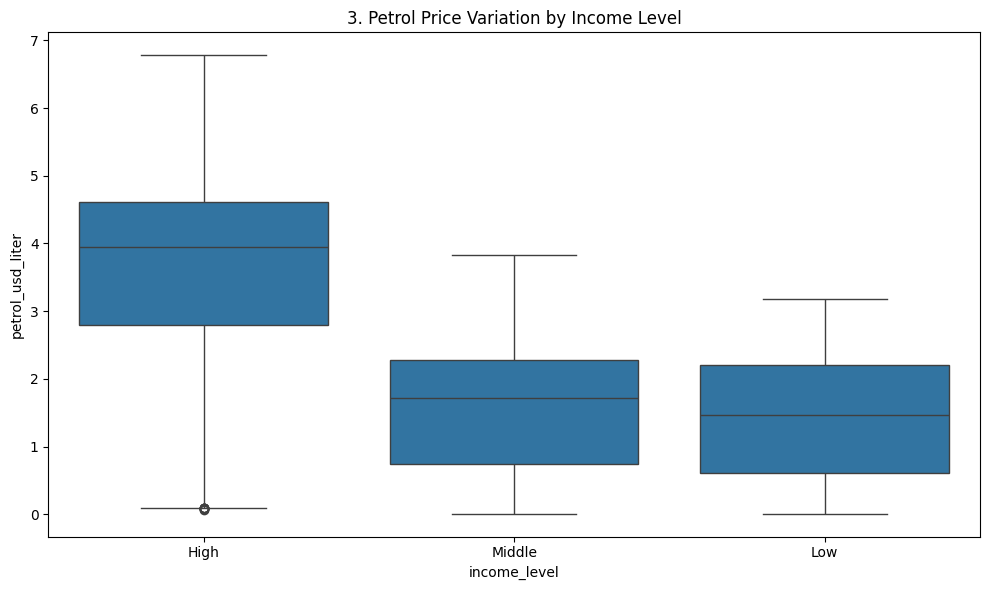

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='income_level', y='petrol_usd_liter', data=df)
plt.title(f'{plot_no}. Petrol Price Variation by Income Level')
show_fig()
plot_no += 1

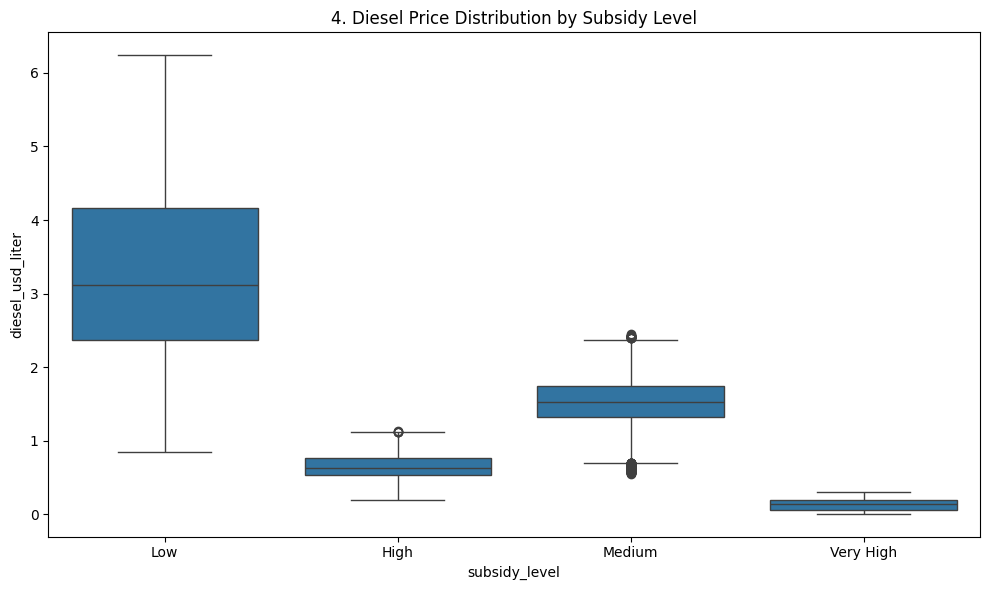

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='subsidy_level', y='diesel_usd_liter', data=df)
plt.title(f'{plot_no}. Diesel Price Distribution by Subsidy Level')
show_fig()
plot_no += 1

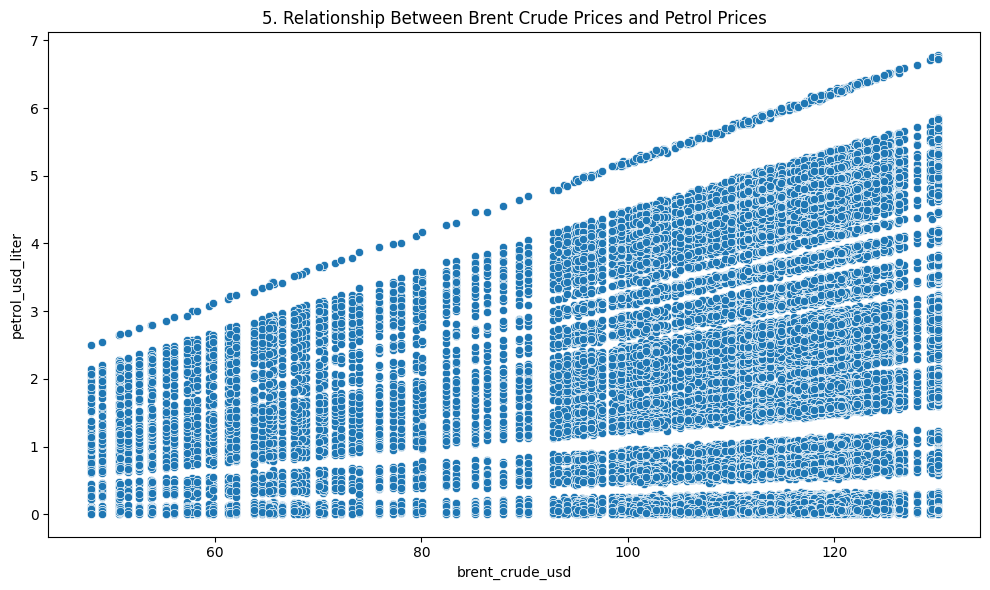

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='brent_crude_usd', y='petrol_usd_liter', data=df)
plt.title(f'{plot_no}. Relationship Between Brent Crude Prices and Petrol Prices')
show_fig()
plot_no += 1

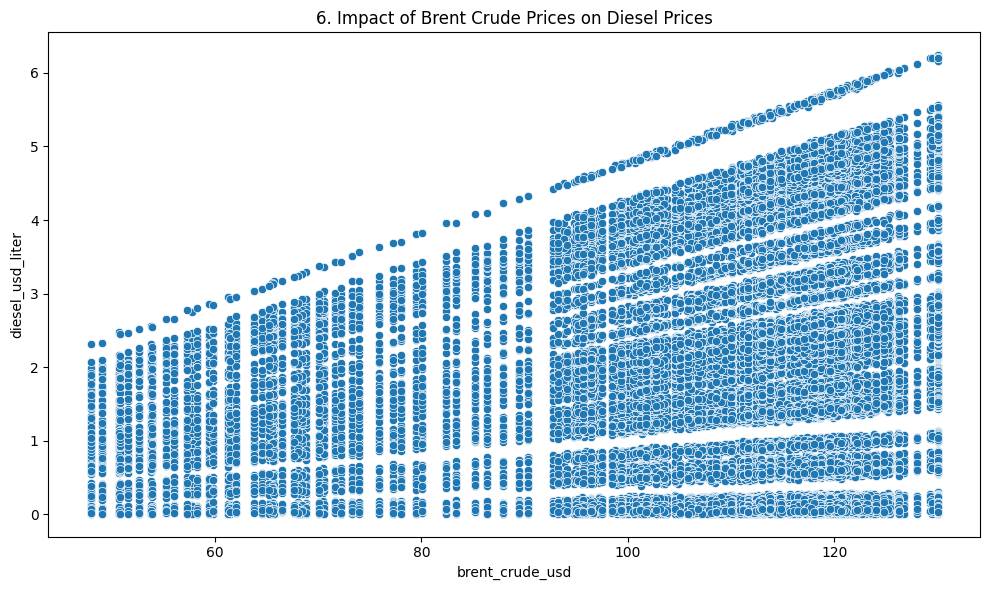

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='brent_crude_usd', y='diesel_usd_liter', data=df)
plt.title(f'{plot_no}. Impact of Brent Crude Prices on Diesel Prices')
show_fig()
plot_no += 1

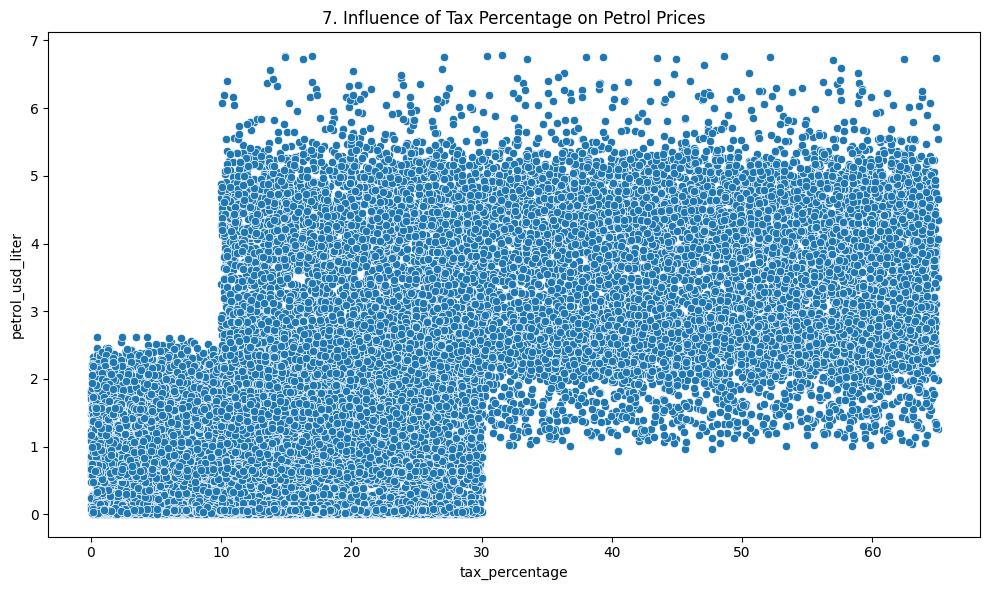

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='tax_percentage', y='petrol_usd_liter', data=df)
plt.title(f'{plot_no}. Influence of Tax Percentage on Petrol Prices')
show_fig()
plot_no += 1

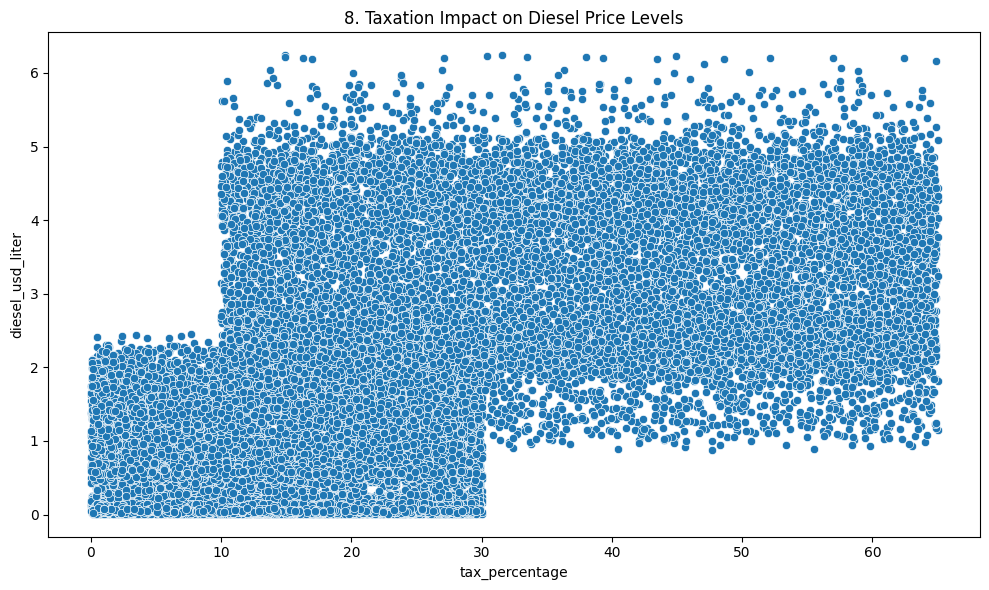

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='tax_percentage', y='diesel_usd_liter', data=df)
plt.title(f'{plot_no}. Taxation Impact on Diesel Price Levels')
show_fig()
plot_no += 1

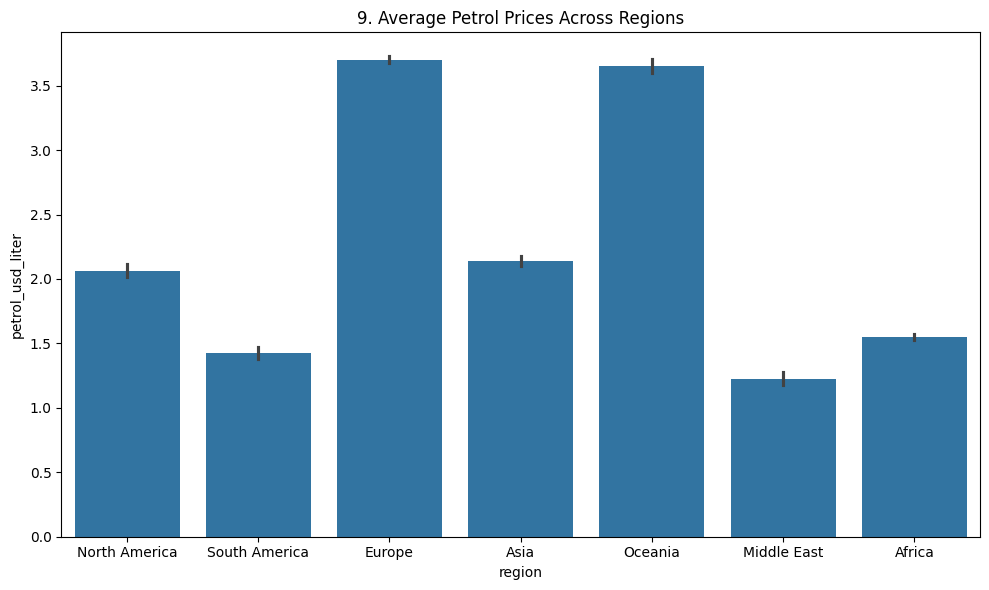

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='region', y='petrol_usd_liter', data=df)
plt.title(f'{plot_no}. Average Petrol Prices Across Regions')
show_fig()
plot_no += 1

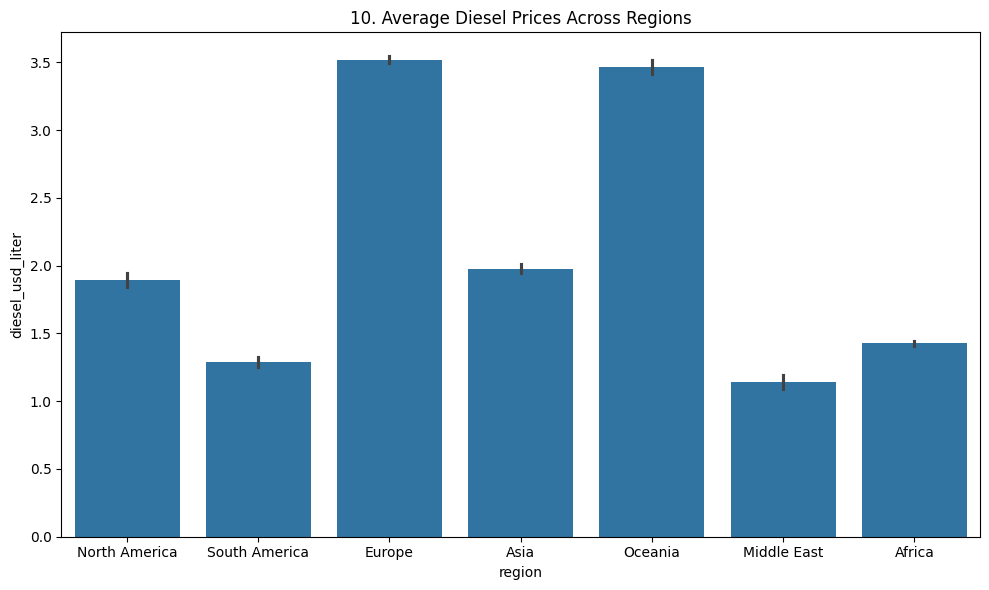

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='region', y='diesel_usd_liter', data=df)
plt.title(f'{plot_no}. Average Diesel Prices Across Regions')
show_fig()
plot_no += 1

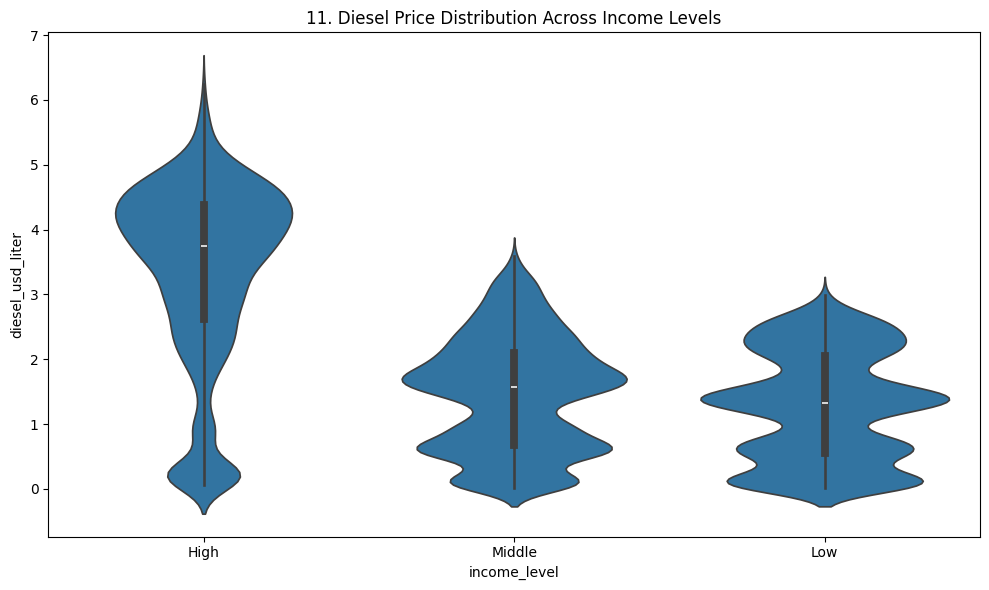

In [23]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='income_level', y='diesel_usd_liter', data=df)
plt.title(f'{plot_no}. Diesel Price Distribution Across Income Levels')
show_fig()
plot_no += 1

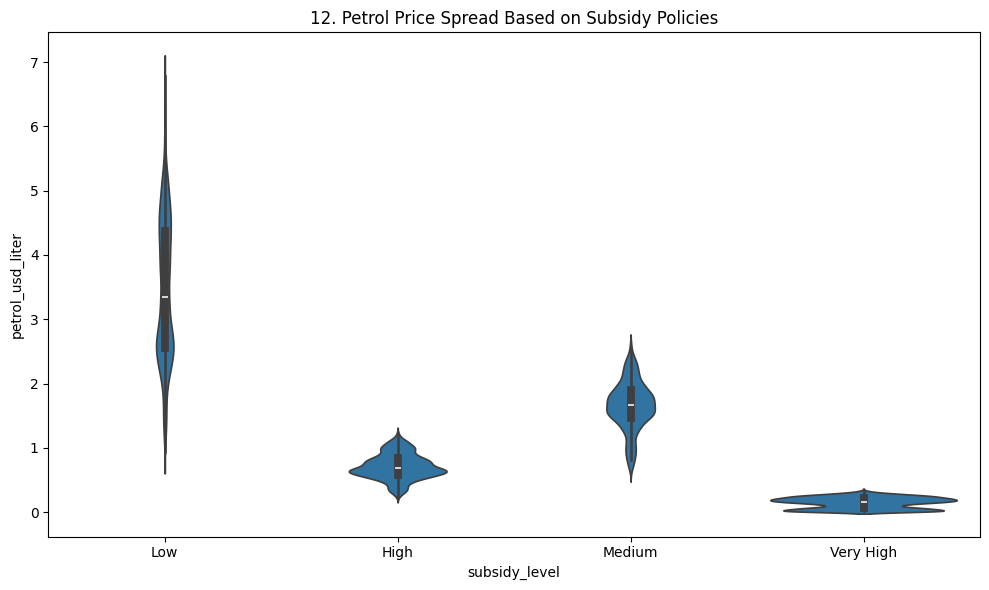

In [24]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='subsidy_level', y='petrol_usd_liter', data=df)
plt.title(f'{plot_no}. Petrol Price Spread Based on Subsidy Policies')
show_fig()
plot_no += 1

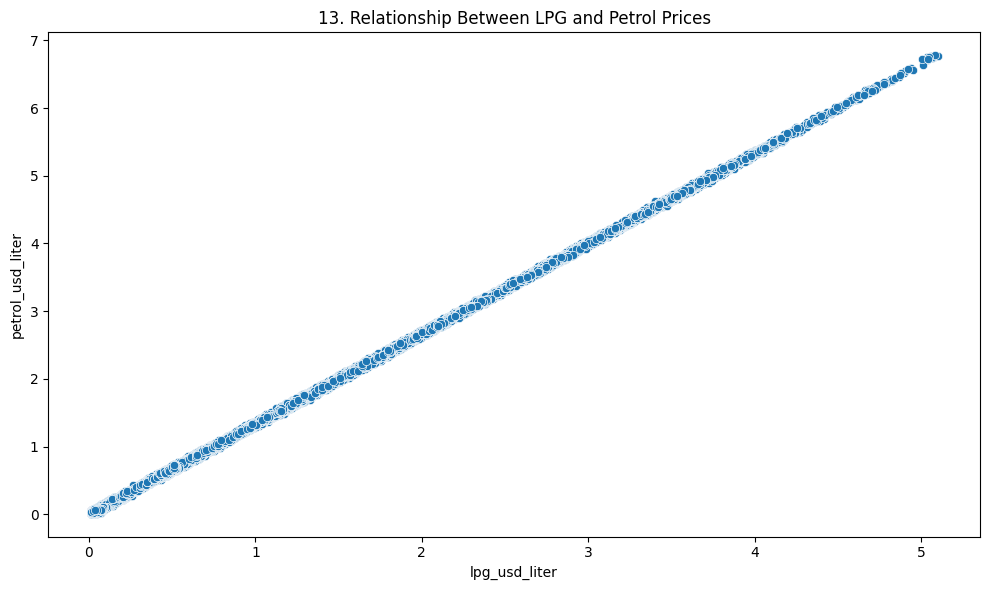

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='lpg_usd_liter', y='petrol_usd_liter', data=df)
plt.title(f'{plot_no}. Relationship Between LPG and Petrol Prices')
show_fig()
plot_no += 1

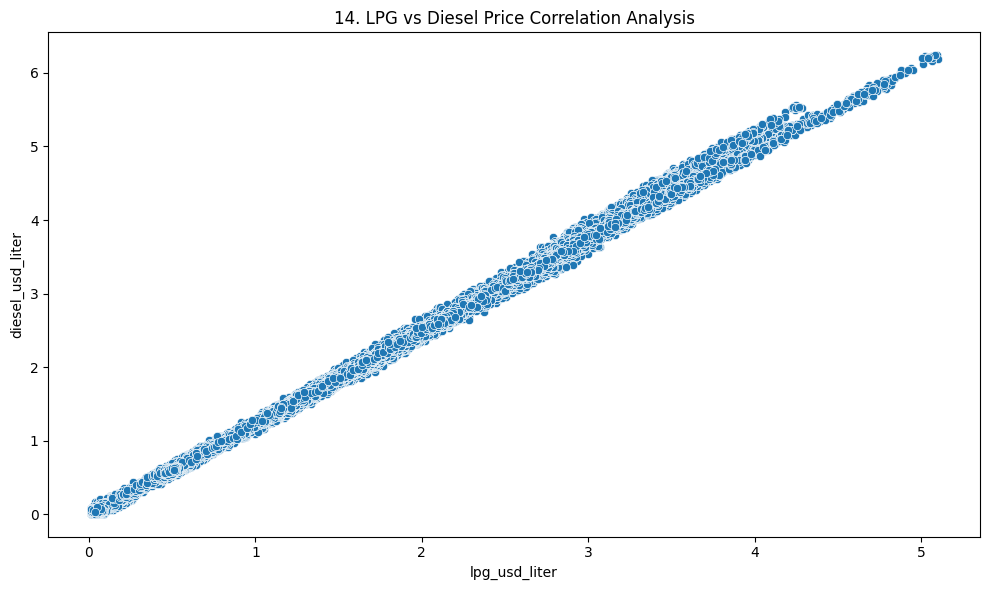

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='lpg_usd_liter', y='diesel_usd_liter', data=df)
plt.title(f'{plot_no}. LPG vs Diesel Price Correlation Analysis')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

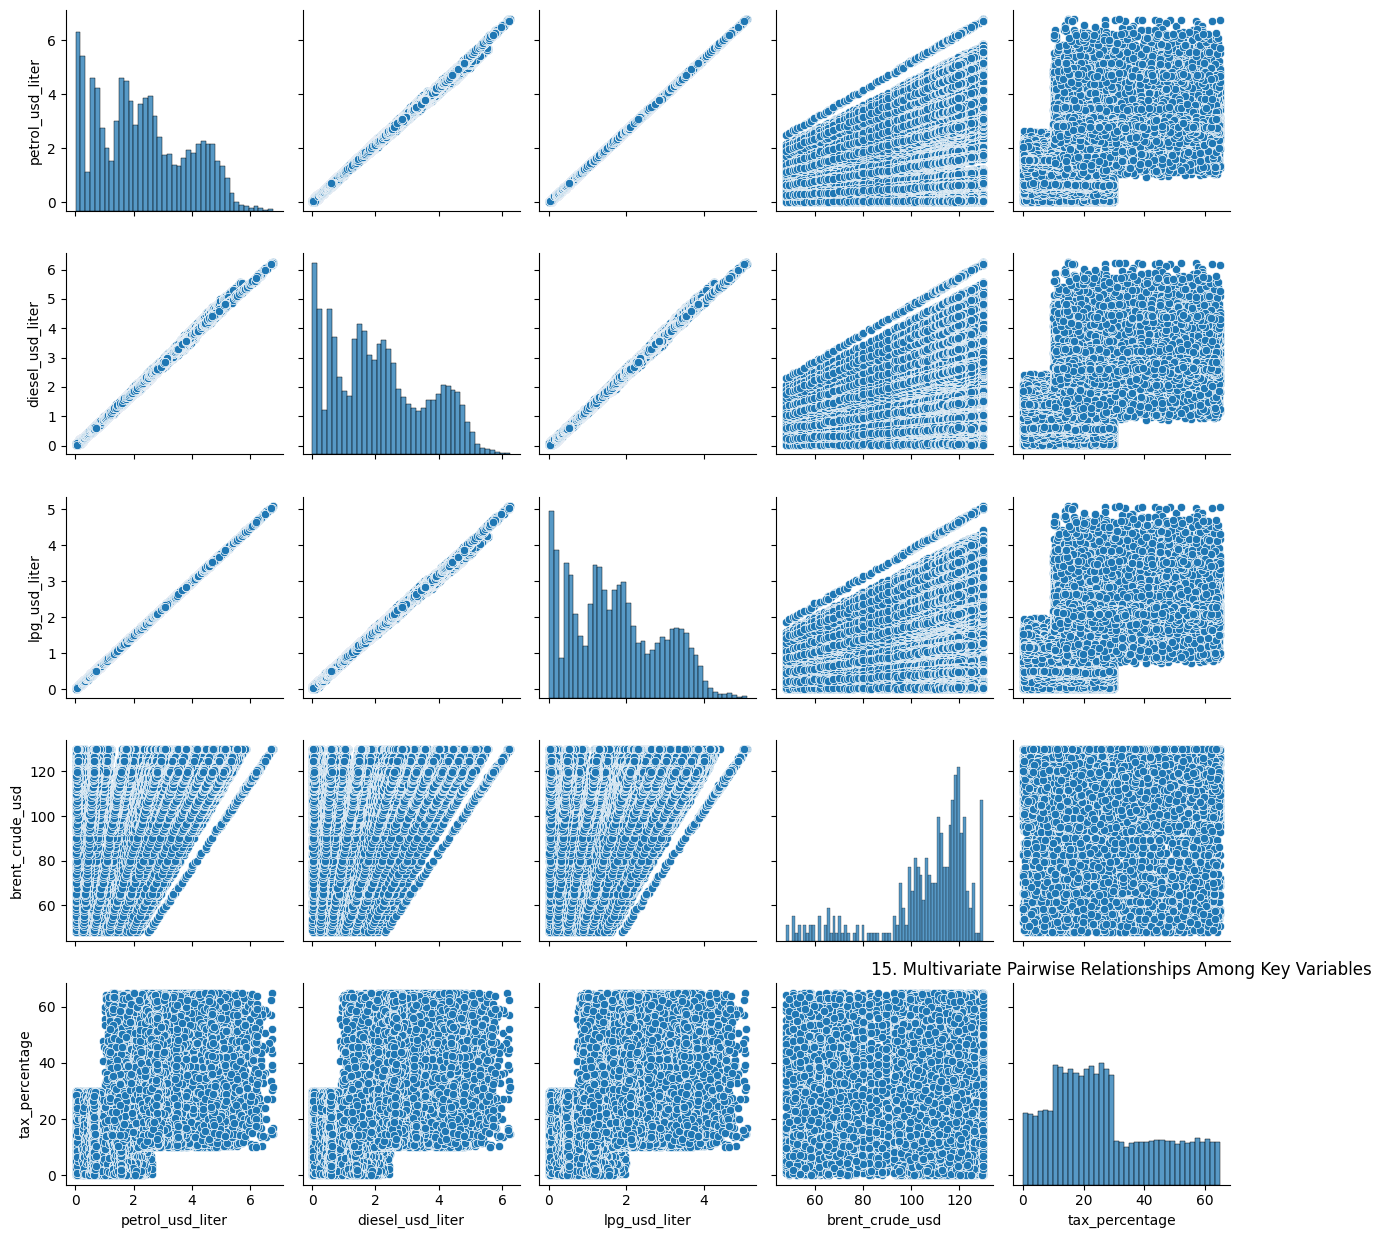

In [27]:
fig = plt.figure(figsize=(10,6))
sns.pairplot(df[['petrol_usd_liter','diesel_usd_liter','lpg_usd_liter','brent_crude_usd','tax_percentage']])
plt.title(f'{plot_no}. Multivariate Pairwise Relationships Among Key Variables')
show_fig()
plot_no += 1

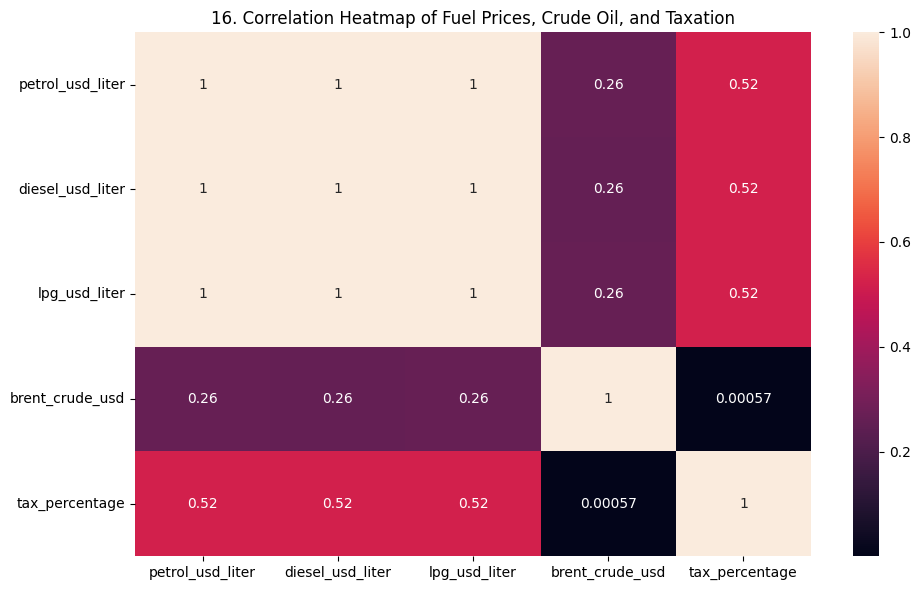

In [28]:
fig = plt.figure(figsize=(10,6))
corr = df[['petrol_usd_liter','diesel_usd_liter','lpg_usd_liter','brent_crude_usd','tax_percentage']].corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Fuel Prices, Crude Oil, and Taxation')
show_fig()
plot_no += 1

# Model Training

## select features and target

In [29]:
X = df[['diesel_usd_liter','lpg_usd_liter','brent_crude_usd','tax_percentage']]
y = df['petrol_usd_liter']

## split data into training and testing

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply scaling

In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train model

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## make predictions

In [33]:
y_pred = model.predict(X_test)

## calculate accuracy (R2 score)

In [34]:
score = r2_score(y_test, y_pred)
print("Model Accuracy (R2 Score):", score)

Model Accuracy (R2 Score): 0.999851656978125


## plot actual vs predicted

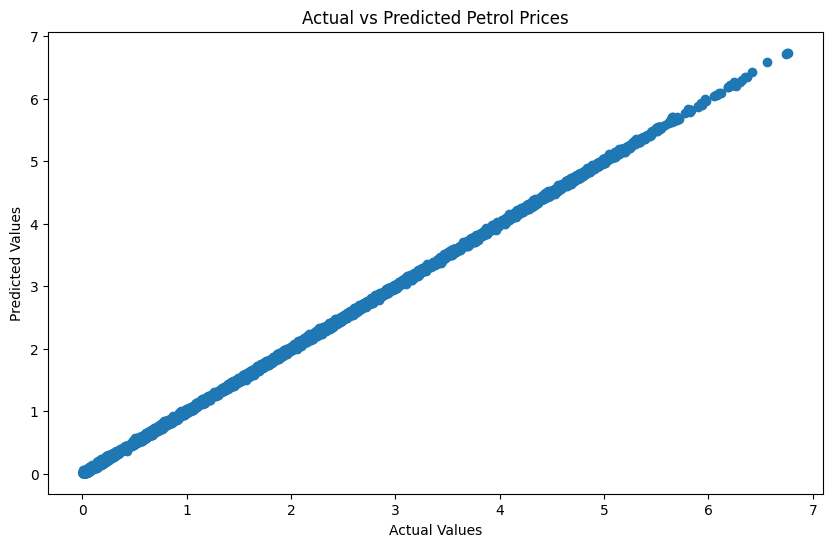

In [35]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Petrol Prices")
plt.show()